# Meta-Transfer Learning Experiment (Transformer)

## 实验概述
本实验旨在对比 **基础迁移学习 (Basic Transfer Learning)** 与 **元迁移学习 (Meta-Transfer Learning)** 在血糖预测任务上的表现，特别是针对 **小样本 (Few-shot)** 场景的泛化能力。

### 方法对比
1. **Basic Transfer Learning**:
   - **预训练**: 在所有源域受试者的大规模混合数据集上进行标准的监督学习训练 (Standard Pre-training)。
   - **微调**: 在目标受试者数据上进行微调。
   - **代表模型**: 加载 `../Prediction/Transformer/transformer_model.pth`。

2. **Meta-Transfer Learning (Reptile Algorithm)**:
   - **元训练**: 使用 **Reptile** (一种一阶 MAML 近似算法) 在源域受试者上进行训练。
   - **核心思想**: 寻找一个对所有任务（受试者）都"敏感"的初始化参数 $\theta$，使得该参数只需少量梯度更新即可快速适应新任务。
   - **微调**: 使用同样的微调策略适应目标受试者。

### 实验目标
- 探究在微调数据量极少 (如 10, 30, 50 个样本) 的情况下，Meta-Learning 获得的初始化参数是否比 Standard Pre-training 更优秀。
- 绘制 **学习曲线 (Learning Curve)** 对比图。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
import os
import math
import copy
import random

# 设置绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. 数据准备
加载源域数据 (Source Tasks) 和目标域数据 (Target Task)。
- **Source**: `Train.csv` (包含多个受试者)
- **Target**: `served.csv` (受试者 124)

In [2]:
# --- 加载数据 ---
train_path = '../DataSplit/TrainTest/Train.csv'
served_path = '../DataSplit/Served/served.csv'

# 读取源数据 (用于 Meta-Training)
df_train_full = pd.read_csv(train_path, parse_dates=['time'])
print(f"源数据加载完成: {len(df_train_full)} 条记录, 受试者数: {df_train_full['id'].nunique()}")

# 读取目标数据 (Subject)
df_served = pd.read_csv(served_path, parse_dates=['time'])
# 124 306
TARGET_ID = 306
df_target = df_served[df_served['id'] == TARGET_ID].copy().sort_values('time').reset_index(drop=True)
print(f"目标受试者 ({TARGET_ID}) 数据加载完成: {len(df_target)} 条记录")

源数据加载完成: 97814 条记录, 受试者数: 164
目标受试者 (306) 数据加载完成: 2760 条记录


## 2. 模型定义 & 数据集类
复用 Transformer 模型结构，保持与基础实验一致。

In [3]:
# --- 模型超参数 ---
N_PAST = 12
PREDICTION_HORIZON = 6
FEATURE_SIZE = 1
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
STATIC_LEN = 2
DROPOUT = 0.1

# --- 数据集类 ---
class GlucoseDataset(Dataset):
    def __init__(self, X, y, n_past):
        self.X_seq = torch.FloatTensor(X[:, :n_past]).unsqueeze(1)
        self.X_static = torch.FloatTensor(X[:, n_past:])
        self.y = torch.FloatTensor(y).unsqueeze(1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

def create_dataset_from_df(data, n_past, prediction_horizon=1):
    X, y = [], []
    gl_values = data['gl'].values
    gl_values = np.clip(gl_values, 40, 400)
    
    age = data['age'].iloc[0]
    bmi = data['bmi'].iloc[0]
    
    if len(gl_values) < n_past + prediction_horizon:
        return np.array([]), np.array([])
    
    for i in range(n_past, len(gl_values) - prediction_horizon + 1):
        past_gl = gl_values[i-n_past:i]
        features = np.append(past_gl, [age, bmi])
        X.append(features)
        y.append(gl_values[i + prediction_horizon - 1])
    
    return np.array(X), np.array(y)

# --- Transformer 模型 ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class GlucoseTransformer(nn.Module):
    def __init__(self, feature_size=1, d_model=64, nhead=4, num_layers=2, static_len=2, dropout=0.1):
        super(GlucoseTransformer, self).__init__()
        self.input_embedding = nn.Linear(feature_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc1 = nn.Linear(d_model + static_len, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x_seq, x_static):
        x = x_seq.permute(0, 2, 1)
        x = self.input_embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        x = torch.cat((x, x_static), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [4]:
# --- 数据预处理 (Standardization) ---
# 为了公平对比，我们使用基于全体源数据训练的 Scaler
X_all_source = []
for pid, group in df_train_full.groupby('id'):
    x_tmp, _ = create_dataset_from_df(group, N_PAST, PREDICTION_HORIZON)
    if len(x_tmp) > 0:
        X_all_source.append(x_tmp)
X_all_source = np.concatenate(X_all_source, axis=0)

scaler = StandardScaler()
scaler.fit(X_all_source)
print("Scaler fitted on Source Data.")

Scaler fitted on Source Data.


## 3. Meta-Training (MAML)
在此阶段，我们训练一个新的模型 `meta_model`。
**MAML (Model-Agnostic Meta-Learning) 算法流程**:
1. 初始化模型参数 $\theta$
2. 循环多次 (Meta-Iterations):
   - 采样一批任务 $T_i$
   - 对每个任务，将数据分为 **Support Set (支持集)** 和 **Query Set (查询集)**
   - **Inner Loop**: 在 Support Set 上进行 $k$ 步梯度下降，得到适应后的临时参数 $\theta'$
   - **Outer Loop**:计算 $\theta'$ 在 Query Set 上的损失，并计算该损失对原参数 $\theta$ 的梯度 (通常使用 FOMAML 近似)
   - 更新元参数 $\theta$以最小化 Query Set 上的 Loss


Preparing source tasks for Meta-Learning...
Created 164 source tasks.
🔥 Warm Start: Loading pretrained weights from ../Prediction/Transformer/transformer_model.pth ...
Start Meta-Training (MAML - FOMAML Approx) | Epochs: 1000
Meta-Iter [10/1000] - Loss: 68.5203 - Fail Rate: 0.0%
Meta-Iter [20/1000] - Loss: 31.1583 - Fail Rate: 0.0%
Meta-Iter [30/1000] - Loss: 32.6680 - Fail Rate: 0.0%
Meta-Iter [40/1000] - Loss: 36.4767 - Fail Rate: 0.0%
Meta-Iter [50/1000] - Loss: 56.3509 - Fail Rate: 0.0%
Meta-Iter [60/1000] - Loss: 44.1903 - Fail Rate: 0.0%
Meta-Iter [70/1000] - Loss: 48.3014 - Fail Rate: 0.0%
Meta-Iter [80/1000] - Loss: 33.2636 - Fail Rate: 0.0%
Meta-Iter [90/1000] - Loss: 31.8182 - Fail Rate: 0.0%
Meta-Iter [100/1000] - Loss: 38.7651 - Fail Rate: 0.0%
Meta-Iter [110/1000] - Loss: 48.8470 - Fail Rate: 0.0%
Meta-Iter [120/1000] - Loss: 26.9745 - Fail Rate: 0.0%
⏹️ Early stopping triggered at iteration 126
Meta-Training Finished (MAML).
Restoring best model with Loss: 22.0345


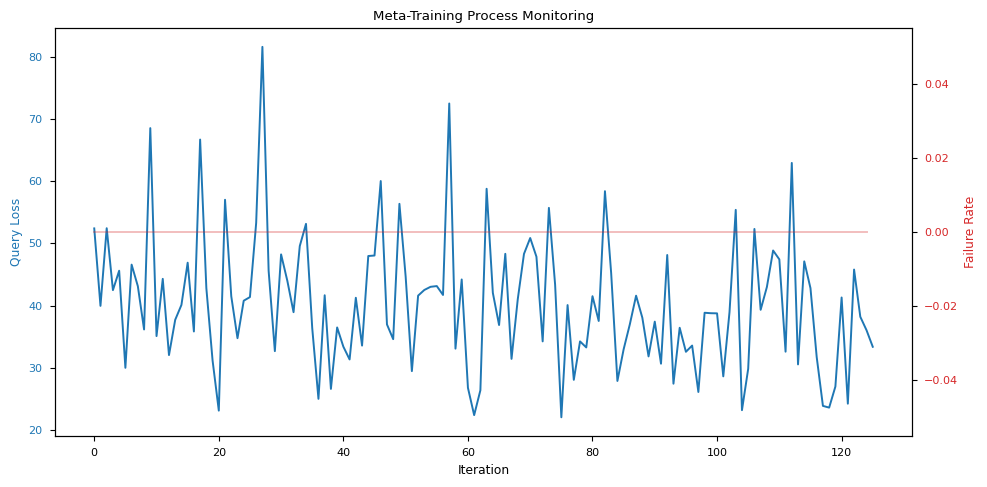

In [5]:
# --- 准备 Meta-Training ---

# 1. 将源数据整理为 {subject_id: (X, y)} 的字典
source_tasks = {}
print("Preparing source tasks for Meta-Learning...")
for pid, group in df_train_full.groupby('id'):
    if len(group) < 200: continue
    X_sub, y_sub = create_dataset_from_df(group, N_PAST, PREDICTION_HORIZON)
    if len(X_sub) > 0:
        X_sub_scaled = scaler.transform(X_sub)
        source_tasks[pid] = (X_sub_scaled, y_sub)

task_ids = list(source_tasks.keys())
print(f"Created {len(task_ids)} source tasks.")

# 2. 初始化 Meta 模型 (Warm Start)
meta_model = GlucoseTransformer(
    feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
    num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
).to(device)

# 加载预训练权重 (Warm Start)
basic_model_path = '../Prediction/Transformer/transformer_model.pth'
if os.path.exists(basic_model_path):
    print(f"🔥 Warm Start: Loading pretrained weights from {basic_model_path} ...")
    meta_model.load_state_dict(torch.load(basic_model_path, map_location=device))
else:
    print("⚠️ Warning: Pretrained model not found. Training from scratch.")

# --- MAML 超参数 (调优版) ---
META_EPOCHS = 1000     # 增加 Epochs
INNER_STEPS = 5        # 增加内循环步数 (5-8)
INNER_LR = 1e-3        # 增大 Inner LR
META_LR = 1e-4         # 恢复 Meta LR
TASK_BATCH_SIZE = 8    # 增大 Task Batch (6-8)
SUPPORT_SIZE = 64      # 增大 Support Set
QUERY_SIZE = 64        # 增大 Query Set
PATIENCE = 50          # Early Stopping Patience

# Outer Optimizer & Scheduler
meta_optimizer = optim.Adam(meta_model.parameters(), lr=META_LR, weight_decay=1e-5) # Add weight_decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(meta_optimizer, mode='min', factor=0.5, patience=20)
criterion = nn.MSELoss()

print(f"Start Meta-Training (MAML - FOMAML Approx) | Epochs: {META_EPOCHS}")

# --- MAML Training Loop ---
meta_model.train()
loss_history = []
failure_history = []
best_loss = float('inf')
patience_counter = 0
best_model_state = None

for iteration in range(META_EPOCHS):
    meta_optimizer.zero_grad()
    meta_batch_loss = 0.0
    valid_tasks_count = 0
    failed_tasks_count = 0
    
    # 随机采样一批任务
    sampled_ids = random.sample(task_ids, min(len(task_ids), TASK_BATCH_SIZE))
    
    task_gradients = {n: torch.zeros_like(p) for n, p in meta_model.named_parameters() if p.requires_grad}
    
    for task_id in sampled_ids:
        X_all, y_all = source_tasks[task_id]
        
        # Split Support / Query
        if len(X_all) < SUPPORT_SIZE + QUERY_SIZE:
             # 如果数据不够，直接跳过该 task
             failed_tasks_count += 1
             continue

        indices = np.random.choice(len(X_all), SUPPORT_SIZE + QUERY_SIZE, replace=False)
        support_idx = indices[:SUPPORT_SIZE]
        query_idx = indices[SUPPORT_SIZE:]
        
        X_sup = torch.FloatTensor(X_all[support_idx]).to(device)
        y_sup = torch.FloatTensor(y_all[support_idx]).unsqueeze(1).to(device)
        X_sup_seq = X_sup[:, :N_PAST].unsqueeze(1)
        X_sup_stat = X_sup[:, N_PAST:]
        
        X_bry = torch.FloatTensor(X_all[query_idx]).to(device)
        y_bry = torch.FloatTensor(y_all[query_idx]).unsqueeze(1).to(device)
        X_bry_seq = X_bry[:, :N_PAST].unsqueeze(1)
        X_bry_stat = X_bry[:, N_PAST:]
        
        # --- Inner Loop (Adaptation) ---
        # Clone model (Fast Weights)
        fast_model = copy.deepcopy(meta_model)
        fast_model.train()
        # Change Inner Optimizer to Adam
        fast_optim = optim.Adam(fast_model.parameters(), lr=INNER_LR)
        
        task_failed = False
        for _ in range(INNER_STEPS):
            fast_optim.zero_grad()
            pred = fast_model(X_sup_seq, X_sup_stat)
            loss = criterion(pred, y_sup)
            
            if torch.isnan(loss):
                task_failed = True
                break
                
            loss.backward()
            # Inner Loop Gradient Clipping
            torch.nn.utils.clip_grad_norm_(fast_model.parameters(), max_norm=1.0)
            fast_optim.step()
            
        if task_failed:
            failed_tasks_count += 1
            continue

        # --- Outer Loop (Loss Evaluation) ---
        pred_bry = fast_model(X_bry_seq, X_bry_stat)
        loss_bry = criterion(pred_bry, y_bry)
        
        if torch.isnan(loss_bry):
            failed_tasks_count += 1
            continue
            
        meta_batch_loss += loss_bry.item()
        valid_tasks_count += 1
        
        # 计算 Query Set 的梯度 (FOMAML)
        loss_bry.backward()
        
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(fast_model.parameters(), max_norm=1.0)

        # 累积梯度
        for n, p in fast_model.named_parameters():
             if p.grad is not None and n in task_gradients:
                 if torch.isnan(p.grad).any():
                     continue
                 task_gradients[n] += p.grad.data / len(sampled_ids)
                 
    # --- Meta Update ---
    if valid_tasks_count > 0:
        for n, p in meta_model.named_parameters():
            if n in task_gradients:
                p.grad = task_gradients[n]
        
        torch.nn.utils.clip_grad_norm_(meta_model.parameters(), max_norm=1.0)
        meta_optimizer.step()
        
        avg_loss = meta_batch_loss / valid_tasks_count
        loss_history.append(avg_loss)
        scheduler.step(avg_loss)
        
        # Early Stopping Check
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(meta_model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= PATIENCE:
             print(f"⏹️ Early stopping triggered at iteration {iteration+1}")
             break
    else:
        loss_history.append(float('nan'))
        
    failure_history.append(failed_tasks_count / len(sampled_ids))

    if (iteration + 1) % 10 == 0:
        print(f"Meta-Iter [{iteration+1}/{META_EPOCHS}] - Loss: {loss_history[-1]:.4f} - Fail Rate: {failure_history[-1]:.1%}")

print("Meta-Training Finished (MAML).")

# Restore Best Model
if best_model_state is not None:
    print(f"Restoring best model with Loss: {best_loss:.4f}")
    meta_model.load_state_dict(best_model_state)

# --- 绘制 Loss 曲线和失败率 ---
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Query Loss', color=color)
ax1.plot(loss_history, color=color, label='Meta Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Failure Rate', color=color)  
ax2.plot(failure_history, color=color, alpha=0.3, label='Fail Rate')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Meta-Training Process Monitoring")
fig.tight_layout()  
plt.show()


## 4. 实验：小样本泛化能力对比 (Learning Curve)

**对比对象**:
1. **Basic Transfer**: 加载预训练好的 `transformer_model.pth` (在 TrainTest.csv 上常规训练得到)。
2. **Meta Transfer**: 使用上面刚刚训练好的 `meta_model` (Reptile 初始化)。

**实验设置**:
- 固定测试集: Subject的后 50% 数据。
- 动态训练集: Subject的前 50% 数据 (Pool) 中的最后 `N` 个样本 (Closest to Test set)。
- 样本梯度: `[10, 30, 50, 100, 200, All]`。
- 评估: 微调后的 MAE/RMSE。

In [6]:
# --- 加载 Basic Pre-trained Model ---
# 假设已经存在该模型文件，如果不存在则发出警告
basic_model_path = '../Prediction/Transformer/transformer_model.pth'
basic_model_state = None
if os.path.exists(basic_model_path):
    print(f"Loading Basic Pre-trained model from {basic_model_path}")
    basic_model_state = torch.load(basic_model_path, map_location=device)
else:
    print("⚠️ Warning: Basic Pre-trained model not found! Please run transformer_prediction.ipynb first.")
    # 为了演示，如果没找到文件，我们暂且用随机初始化代替 (但这会导致实验无效)
    # basic_model_state = GlucoseTransformer(...).state_dict()

# --- 准备 Target Data ---
# 划分 Pool / Test
TEST_RATIO = 0.5
split_idx = int(len(df_target) * (1 - TEST_RATIO))

df_pool = df_target.iloc[:split_idx].copy()

# 修正: 确保测试集的连续性，避免因窗口构建产生的时间缝隙 (Gap)
# 我们需要从 Pool 的末尾借用一段数据作为 Test 序列开头的 History Context
overlap_size = N_PAST + PREDICTION_HORIZON - 1
# 确保索引不越界
start_test_idx = max(0, split_idx - overlap_size)
df_test = df_target.iloc[start_test_idx:].copy()

X_pool, y_pool = create_dataset_from_df(df_pool, N_PAST, PREDICTION_HORIZON)
X_test, y_test = create_dataset_from_df(df_test, N_PAST, PREDICTION_HORIZON)

# 验证连续性：X_pool 的最后一个 y 和 X_test 的第一个 y 应该是时间上相邻的
# print(f"Pool ends at index {split_idx-1}, Test starts prediction at index {split_idx}")

X_pool_scaled = scaler.transform(X_pool)
X_test_scaled = scaler.transform(X_test)
test_ds = GlucoseDataset(X_test_scaled, y_test, N_PAST)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Target Pool Size: {len(X_pool)}")
print(f"Target Test Size: {len(X_test)}")

# --- 微调与评估函数 ---
def fine_tune_and_evaluate(init_state_dict, X_train, y_train, epochs=30, lr=1e-3, freeze_encoder=False):
    # 1. Init Model
    model = GlucoseTransformer(
        feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
        num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
    ).to(device)
    model.load_state_dict(init_state_dict)
    
    # 2. Freeze Logic (Optional)
    if freeze_encoder:
        for param in model.parameters(): param.requires_grad = False
        for param in model.fc1.parameters(): param.requires_grad = True
        for param in model.fc2.parameters(): param.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    else:
        # Full Fine-tuning
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
    criterion = nn.MSELoss()
    
    # 3. Train
    ds = GlucoseDataset(X_train, y_train, N_PAST)
    dl = DataLoader(ds, batch_size=16, shuffle=True) # Small batch for few-shot
    
    model.train()
    for _ in range(epochs):
        for bx, bs, by in dl:
            bx, bs, by = bx.to(device), bs.to(device), by.to(device)
            optimizer.zero_grad()
            out = model(bx, bs)
            loss = criterion(out, by)
            
            # Loss 为 NaN Check
            if torch.isnan(loss):
                print("Warning: NaN loss detected during fine-tuning given batch.")
                continue

            loss.backward()
            
            # 加上梯度截断
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
    # 4. Evaluate
    model.eval()
    preds = []
    with torch.no_grad():
        for bx, bs, _ in test_loader:
            bx, bs = bx.to(device), bs.to(device)
            out = model(bx, bs)
            preds.extend(out.cpu().numpy())
    preds = np.array(preds).flatten()
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse


Loading Basic Pre-trained model from ../Prediction/Transformer/transformer_model.pth
Target Pool Size: 1363
Target Test Size: 1380


In [7]:
# --- 运行对比实验 ---
sample_sizes = [10, 30, 50, 100, 200, len(X_pool)]
results_basic = {'MAE': [], 'RMSE': []}
results_meta = {'MAE': [], 'RMSE': []}

print("Starting Comparative Experiment...")

for n in sample_sizes:
    n = min(n, len(X_pool)) # Clamp
    print(f"Testing with N={n} samples...")
    
    # Current Training Subset (取最后 n 个样本，即离测试集最近的数据)
    X_sub = X_pool_scaled[-n:]
    y_sub = y_pool[-n:]
    
    # 1. Basic Transfer
    if basic_model_state is not None:
        mae, rmse = fine_tune_and_evaluate(basic_model_state, X_sub, y_sub, epochs=40, lr=1e-3, freeze_encoder=True)
        results_basic['MAE'].append(mae)
        results_basic['RMSE'].append(rmse)
    
    # 2. Meta Transfer
    # Meta 初始化的优势在于全参数快速适应，通常不 Freeze，或者 Freeze 也行
    # 这里我们对比 "Meta Initialization + Full Tuning" vs "Basic + Freeze Tuning" (常见设定)
    # 或者两者都用同样的 Tuning 策略。为了公平对比初始化质量，我们使用同样的策略。
    # Reptile 的设计初衷是找到一个好的全参数初始化，所以我们尝试全参数微调 (Full Finetune)
    # 但如果是极小样本，Freeze 可能更稳。这里我们尝试 Freeze Encoder 以保持一致性。
    mae_m, rmse_m = fine_tune_and_evaluate(meta_model.state_dict(), X_sub, y_sub, epochs=40, lr=1e-3, freeze_encoder=True)
    results_meta['MAE'].append(mae_m)
    results_meta['RMSE'].append(rmse_m)
    
print("Experiment Done.")

Starting Comparative Experiment...
Testing with N=10 samples...
Testing with N=30 samples...
Testing with N=50 samples...
Testing with N=100 samples...
Testing with N=200 samples...
Testing with N=1363 samples...
Experiment Done.


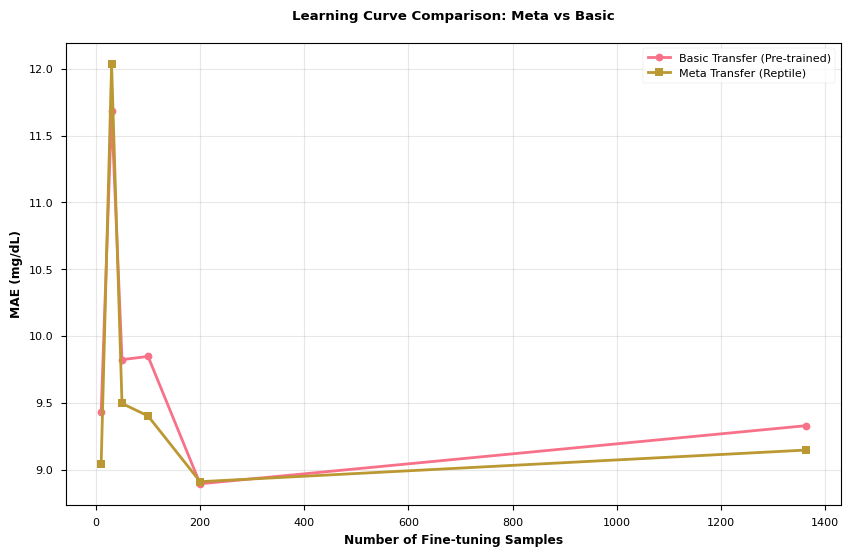

   Samples  Basic_MAE   Meta_MAE
0       10   9.430318   9.041986
1       30  11.679776  12.036635
2       50   9.822154   9.494625
3      100   9.846722   9.400888
4      200   8.893047   8.909100
5     1363   9.327887   9.145546


In [8]:
# --- 结果可视化 ---
df_res = pd.DataFrame({
    'Samples': sample_sizes,
    'Basic_MAE': results_basic['MAE'],
    'Meta_MAE': results_meta['MAE']
})

plt.figure(figsize=(10, 6))

plt.plot(df_res['Samples'], df_res['Basic_MAE'], marker='o', label='Basic Transfer (Pre-trained)', linewidth=2)
plt.plot(df_res['Samples'], df_res['Meta_MAE'], marker='s', label='Meta Transfer (Reptile)', linewidth=2)

plt.xlabel('Number of Fine-tuning Samples', fontweight='bold')
plt.ylabel('MAE (mg/dL)', fontweight='bold')
plt.title('Learning Curve Comparison: Meta vs Basic\n', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 打印数值
print(df_res)

## 5. 详细预测结果可视化 (Case Study)

为了直观展示 Meta-Learning 在小样本下的优势，我们选择一个具体的微调样本量 (例如 **N=50**)，详细对比 Basic Transfer 与 Meta Transfer 在测试集上的时序预测表现。

In [9]:
# --- 配置可视化案例 ---
N_VISUALIZE = 30  # 选择微调样本数 (Few-shot scenario)

print(f"Generating visualization for N={N_VISUALIZE} few-shot scenario...")

# 准备微调数据 (取最后 N 个样本，即离测试集最近的数据，减少分布偏移)
X_ft = X_pool_scaled[-N_VISUALIZE:]
y_ft = y_pool[-N_VISUALIZE:]

# 1. 训练 Basic Transfer 模型
print("Fine-tuning Basic Transfer Model...")
basic_vis_model = GlucoseTransformer(
    feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
    num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
).to(device)
if basic_model_state is not None:
    basic_vis_model.load_state_dict(basic_model_state)

# 使用与实验相同的训练设置 (Freeze Encoder)
opt_basic = optim.Adam(filter(lambda p: p.requires_grad, basic_vis_model.parameters()), lr=1e-3)
# Freeze logic
for param in basic_vis_model.parameters(): param.requires_grad = False
for param in basic_vis_model.fc1.parameters(): param.requires_grad = True
for param in basic_vis_model.fc2.parameters(): param.requires_grad = True
opt_basic = optim.Adam(filter(lambda p: p.requires_grad, basic_vis_model.parameters()), lr=1e-3)

ds_ft = GlucoseDataset(X_ft, y_ft, N_PAST)
dl_ft = DataLoader(ds_ft, batch_size=16, shuffle=True)
criterion = nn.MSELoss()

basic_vis_model.train()
for _ in range(40):
    for bx, bs, by in dl_ft:
        bx, bs, by = bx.to(device), bs.to(device), by.to(device)
        opt_basic.zero_grad()
        out = basic_vis_model(bx, bs)
        loss = criterion(out, by)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(basic_vis_model.parameters(), max_norm=1.0)
        opt_basic.step()

# 2. 训练 Meta Transfer 模型
print("Fine-tuning Meta Transfer Model...")
meta_vis_model = GlucoseTransformer(
    feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
    num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
).to(device)
meta_vis_model.load_state_dict(meta_model.state_dict()) # Load Meta Params

# Freeze logic
for param in meta_vis_model.parameters(): param.requires_grad = False
for param in meta_vis_model.fc1.parameters(): param.requires_grad = True
for param in meta_vis_model.fc2.parameters(): param.requires_grad = True
opt_meta = optim.Adam(filter(lambda p: p.requires_grad, meta_vis_model.parameters()), lr=1e-3)

meta_vis_model.train()
for _ in range(40):
    for bx, bs, by in dl_ft:
        bx, bs, by = bx.to(device), bs.to(device), by.to(device)
        opt_meta.zero_grad()
        out = meta_vis_model(bx, bs)
        loss = criterion(out, by)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(meta_vis_model.parameters(), max_norm=1.0)
        opt_meta.step()

# --- 进行预测 ---
basic_vis_model.eval()
meta_vis_model.eval()

preds_basic = []
preds_meta = []

with torch.no_grad():
    for bx, bs, _ in test_loader:
        bx, bs = bx.to(device), bs.to(device)
        
        # Basic
        out_b = basic_vis_model(bx, bs)
        preds_basic.extend(out_b.cpu().numpy())
        
        # Meta
        out_m = meta_vis_model(bx, bs)
        preds_meta.extend(out_m.cpu().numpy())

preds_basic = np.array(preds_basic).flatten()
preds_meta = np.array(preds_meta).flatten()

# 计算指标
mae_b = mean_absolute_error(y_test, preds_basic)
mae_m = mean_absolute_error(y_test, preds_meta)

print(f"Validation Results (N={N_VISUALIZE}):")
print(f"Basic Transfer MAE: {mae_b:.4f}")
print(f"Meta Transfer MAE : {mae_m:.4f}")


Generating visualization for N=30 few-shot scenario...
Fine-tuning Basic Transfer Model...
Fine-tuning Meta Transfer Model...
Validation Results (N=30):
Basic Transfer MAE: 12.2435
Meta Transfer MAE : 11.0484


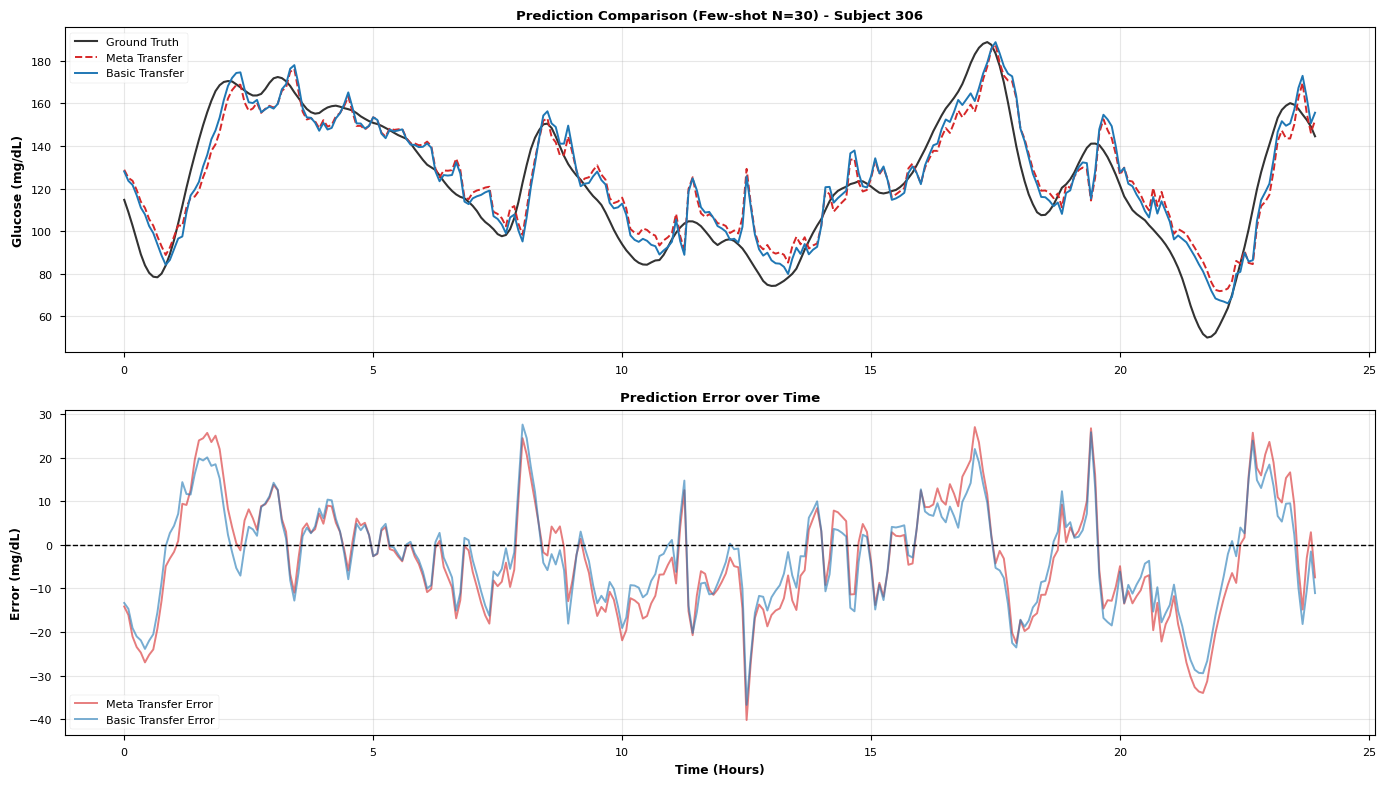

In [10]:
# --- 绘图对比 ---
# 选取一部分测试集时间段进行清晰展示 (例如前 24 小时 = 288 个点)
PLOT_LEN = 288 
if len(y_test) < PLOT_LEN: PLOT_LEN = len(y_test)

time_idx = np.arange(PLOT_LEN) * 5 / 60 # Hours

plt.figure(figsize=(14, 8))

# 1. Prediction Comparison
plt.subplot(2, 1, 1)
plt.plot(time_idx, y_test[:PLOT_LEN], label='Ground Truth', color='black', linewidth=1.5, alpha=0.8)
plt.plot(time_idx, preds_basic[:PLOT_LEN], label=f'Meta Transfer', color='tab:red', linestyle='--')
plt.plot(time_idx, preds_meta[:PLOT_LEN], label=f'Basic Transfer', color='tab:blue')

plt.title(f'Prediction Comparison (Few-shot N={N_VISUALIZE}) - Subject {TARGET_ID}', fontweight='bold')
plt.ylabel('Glucose (mg/dL)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Error Comparison
plt.subplot(2, 1, 2)
err_basic = y_test[:PLOT_LEN] - preds_basic[:PLOT_LEN]
err_meta = y_test[:PLOT_LEN] - preds_meta[:PLOT_LEN]

plt.plot(time_idx, err_basic, label='Meta Transfer Error', color='tab:red', alpha=0.6)
plt.plot(time_idx, err_meta, label='Basic Transfer Error', color='tab:blue', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Time (Hours)', fontweight='bold')
plt.ylabel('Error (mg/dL)', fontweight='bold')
plt.title('Prediction Error over Time', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
# --- 详细指标对比表 ---
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE & RMSPE (注意处理除零)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'RMSPE': rmspe}

m_basic = get_metrics(y_test, preds_basic)
m_meta = get_metrics(y_test, preds_meta)

metrics_df = pd.DataFrame([m_basic, m_meta], index=['Basic Transfer', 'Meta Transfer'])

# 计算提升百分比 (Basic - Meta) / Basic * 100
# 注意: 误差越小越好，所以 (基本误差 - 元误差) / 基本误差 > 0 表示提升
improvement = (metrics_df.loc['Basic Transfer'] - metrics_df.loc['Meta Transfer']) / metrics_df.loc['Basic Transfer'] * 100

# 拼接到 DataFrame
metrics_df.loc['Improvement (%)'] = improvement

print("=" * 65)
print(f"📊 详细性能指标对比 (Few-shot Samples N={N_VISUALIZE})")
print("=" * 65)
# 格式化输出
print(metrics_df.round(4).to_string())
print("=" * 65)


📊 详细性能指标对比 (Few-shot Samples N=30)
                     MAE     RMSE     MAPE    RMSPE
Basic Transfer   12.2435  15.2693   9.6256  13.2049
Meta Transfer    11.0484  14.1959   8.4476  11.5714
Improvement (%)   9.7609   7.0296  12.2382  12.3708


Evaluating performance trend for N = [20, 30, 40, 50, 80, 100, 200] ...
Processing N=20...
Processing N=30...
Processing N=40...
Processing N=50...
Processing N=80...
Processing N=100...
Processing N=200...


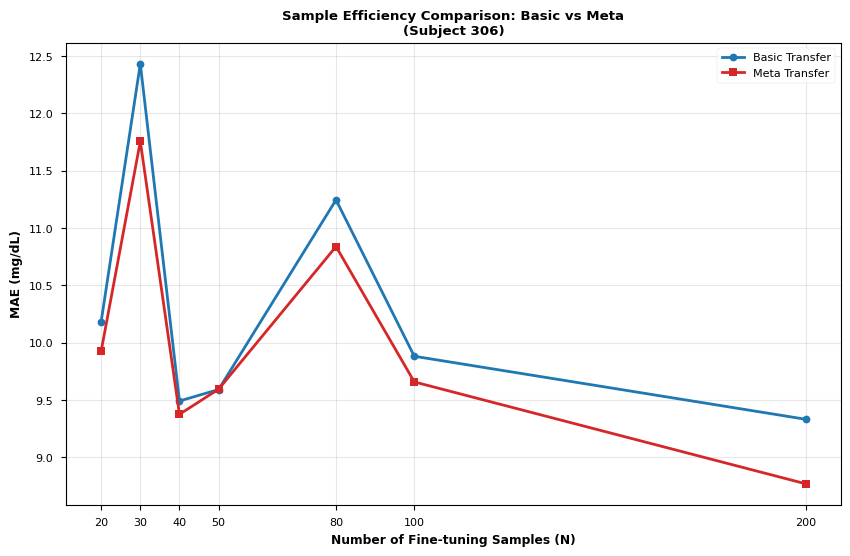

   Samples  Basic MAE  Meta MAE  Improvement
0       20    10.1855    9.9277       2.5316
1       30    12.4326   11.7564       5.4389
2       40     9.4924    9.3762       1.2240
3       50     9.5926    9.5955      -0.0308
4       80    11.2460   10.8392       3.6174
5      100     9.8826    9.6587       2.2658
6      200     9.3330    8.7704       6.0281


In [12]:
# --- 6. 多样本量性能趋势对比 (Multi-N Performance Trend) ---
# 可视化不同微调样本量下 MAE 的变化趋势

N_VALUES = [20,30,40,50,80,100,200]
print(f"Evaluating performance trend for N = {N_VALUES} ...")

results_mae_basic = []
results_mae_meta = []

for n in N_VALUES:
    print(f"Processing N={n}...")
    
    # --- Data Prep ---
    if n > len(X_pool_scaled): n = len(X_pool_scaled)
    # 取最后 n 个样本 (Most Recent)
    X_ft = X_pool_scaled[-n:]
    y_ft = y_pool[-n:]
    ds_ft = GlucoseDataset(X_ft, y_ft, N_PAST)
    dl_ft = DataLoader(ds_ft, batch_size=16, shuffle=True)
    criterion = nn.MSELoss()

    # --- 1. Basic Transfer ---
    model_b = GlucoseTransformer(
        feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
        num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
    ).to(device)
    if basic_model_state is not None:
        model_b.load_state_dict(basic_model_state)
    
    # Freeze & Train params
    for param in model_b.parameters(): param.requires_grad = False
    for param in model_b.fc1.parameters(): param.requires_grad = True
    for param in model_b.fc2.parameters(): param.requires_grad = True
    opt_b = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()), lr=1e-3)
    
    model_b.train()
    for _ in range(40):
        for bx, bs, by in dl_ft:
            bx, bs, by = bx.to(device), bs.to(device), by.to(device)
            opt_b.zero_grad()
            out = model_b(bx, bs)
            loss = criterion(out, by)
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_b.parameters(), max_norm=1.0)
            opt_b.step()

    # --- 2. Meta Transfer ---
    model_m = GlucoseTransformer(
        feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
        num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
    ).to(device)
    model_m.load_state_dict(meta_model.state_dict())
    
    for param in model_m.parameters(): param.requires_grad = False
    for param in model_m.fc1.parameters(): param.requires_grad = True
    for param in model_m.fc2.parameters(): param.requires_grad = True
    opt_m = optim.Adam(filter(lambda p: p.requires_grad, model_m.parameters()), lr=1e-3)
    
    model_m.train()
    for _ in range(40):
        for bx, bs, by in dl_ft:
            bx, bs, by = bx.to(device), bs.to(device), by.to(device)
            opt_m.zero_grad()
            out = model_m(bx, bs)
            loss = criterion(out, by)
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_m.parameters(), max_norm=1.0)
            opt_m.step()
            
    # --- Eval ---
    model_b.eval(); model_m.eval()
    pb, pm = [], []
    with torch.no_grad():
        for bx, bs, _ in test_loader:
            bx, bs = bx.to(device), bs.to(device)
            pb.extend(model_b(bx, bs).cpu().numpy())
            pm.extend(model_m(bx, bs).cpu().numpy())
            
    mae_b = mean_absolute_error(y_test, np.array(pb).flatten())
    mae_m = mean_absolute_error(y_test, np.array(pm).flatten())
    
    results_mae_basic.append(mae_b)
    results_mae_meta.append(mae_m)

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(N_VALUES, results_mae_basic, marker='o', label='Basic Transfer', linewidth=2, color='tab:blue')
plt.plot(N_VALUES, results_mae_meta, marker='s', label='Meta Transfer', linewidth=2, color='tab:red')

plt.xlabel('Number of Fine-tuning Samples (N)', fontweight='bold')
plt.ylabel('MAE (mg/dL)', fontweight='bold')
plt.title(f'Sample Efficiency Comparison: Basic vs Meta\n(Subject {TARGET_ID})', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(N_VALUES)
plt.show()

# Print Data
res_df = pd.DataFrame({
    'Samples': N_VALUES,
    'Basic MAE': results_mae_basic,
    'Meta MAE': results_mae_meta
})
res_df['Improvement'] = (res_df['Basic MAE'] - res_df['Meta MAE']) / res_df['Basic MAE'] * 100
print(res_df.round(4))